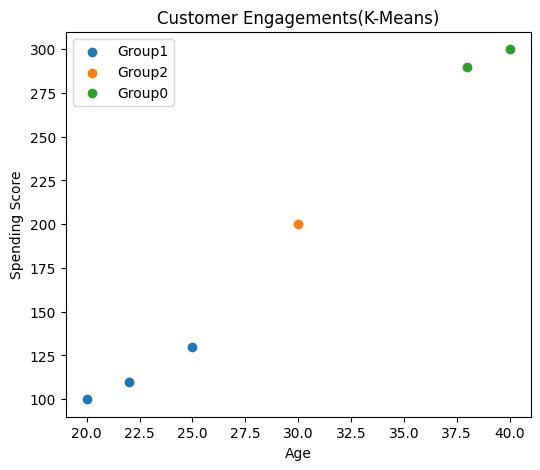

  Customer  Age  Spending  Group
0     Riya   20       100      1
1     Aman   30       200      2
2   Faizan   40       300      0
3     Neha   22       110      1
4    Imran   38       290      0
5    Sneha   25       130      1


In [9]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#sample data
data={
    'Customer':['Riya','Aman','Faizan','Neha','Imran','Sneha'],
    'Age':[20,30,40,22,38,25],
    'Spending':[100,200,300,110,290,130]
}
df=pd.DataFrame(data)

X=df[['Age','Spending']] #using data for clustering

model=KMeans(n_clusters=3,random_state=42,n_init=10)#it will start from different point 10 times that means k-means will run for 10 times and search for best clustering out of those 10 times)

df['Group']=model.fit_predict(X) #divide riya aman and others into two groups ,one will have the value 0 and other will have 1 ,it means some will have 0 and some will have 1 which signifies the group in which everyone is kept)

plt.figure(figsize=(6,5)) #width is 6 and height is 5


#overall flow of this loop below- first filtering group 0 or 1 then it firts runs for loop of 0,take only those datas of 0 like age spending colmn and then it plots them,then same is applied for rows with 1.
#first iteration group=0 then second iteration group=1.
for group in df['Group'].unique():#represent in [0,1] ,mark every group with different colours
    group_data=df[df['Group']==group] #condn check if this group is in 0 or 1  #masking
    plt.scatter(group_data['Age'],group_data['Spending'],label=f'Group{group}') #formatted string
    
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.title('Customer Engagements(K-Means)')
plt.legend()
plt.show()

print(df)


Variance captured by each PCA Component:
[99.65  0.35]


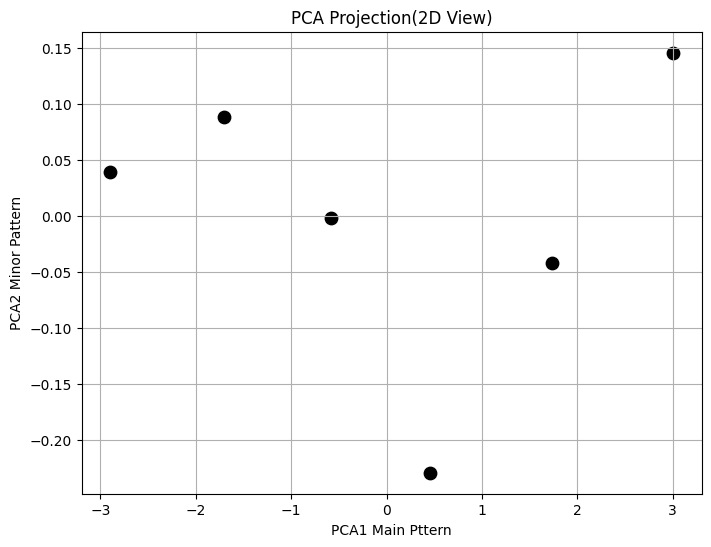

New Data with 2 features PCA1,PCA2
       PCA1      PCA2
0 -2.901838  0.038962
1 -1.703939  0.088054
2 -0.585677 -0.001447
3  0.452949 -0.229542
4  1.730485 -0.041856
5  3.008020  0.145829


In [21]:
#PCA- Principal Component Analysis
#only summarised/important columns are needed
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler #eg age range is 20-50 but income is 50000 which is a large number so scaling is important otherwise 50000 will dominate
from sklearn.decomposition import PCA

data={
    'Age':[25,30,35,40,45,50],
    'Income':[30000,40000,50000,60000,70000,80000],
    'Spending':[70,60,50,40,30,20],
    'Savings':[1000,5000,8000,10000,15000,20000]
}

df=pd.DataFrame(data)

scaler=StandardScaler() #scaler is aobject that contains standard scaler function
scaled_data=scaler.fit_transform(df) #this standard scaler funcn is applied to our dataframe now

pca=PCA(n_components=2) #shrink all colm to 2
pca_result=pca.fit_transform(scaled_data) #scaled data will be converted into pca result

pca_df = pd.DataFrame(pca_result,columns=['PCA1','PCA2'])#names of colmn are passed

explained_variance=pca.explained_variance_ratio_
print("Variance captured by each PCA Component:")
print(np.round(explained_variance*100,2)) #like PCA1 has x percent useful data and PCA2 has 100-x percent useful data
    
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PCA1'],pca_df['PCA2'],color='black',s=80)
plt.title("PCA Projection(2D View)")
plt.xlabel('PCA1 Main Pttern')
plt.ylabel('PCA2 Minor Pattern')
plt.grid(True)
plt.show()

print("New Data with 2 features PCA1,PCA2")
print(pca_df)
      